In [ ]:
import json
import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa
from collections import Counter
from itertools import combinations
import numpy as np

# Load survey data
with open("/home/amandabrooke/2025-promega-mini-test/surveys/organoid_surveys_aggregated.json", "r") as f:
    data = json.load(f)

# Flatten evaluations
records = []
for organoid_id, content in data.items():
    for e in content.get("evaluations", []):
        records.append({
            "organoid_id": organoid_id,
            "employee": e["employee"],
            "evaluation": e["evaluation"]
        })

df = pd.DataFrame(records)

# Convert evaluation to numerical categories
eval_map = {"Acceptable": 1, "Not Acceptable": 0}
df["eval_num"] = df["evaluation"].map(eval_map)

# Create matrix for Fleiss' Kappa: rows are organoids, columns are counts of each category
kappa_matrix = []
organoid_groups = df.groupby("organoid_id")
for name, group in organoid_groups:
    counts = group["eval_num"].value_counts().reindex([0, 1], fill_value=0)
    kappa_matrix.append(counts.tolist())

# Compute Fleiss' Kappa
fk_score = fleiss_kappa(np.array(kappa_matrix))

# Create agreement matrix for pairwise agreement
raters = df["employee"].unique()
pair_agreement = pd.DataFrame(0, index=raters, columns=raters, dtype=float)
pair_counts = pd.DataFrame(0, index=raters, columns=raters, dtype=int)

# Count agreements between each rater pair
for organoid, group in df.groupby("organoid_id"):
    ratings = group.set_index("employee")["eval_num"].to_dict()
    for (r1, r2) in itertools.combinations(ratings.keys(), 2):
        if ratings[r1] == ratings[r2]:
            pair_agreement.loc[r1, r2] += 1
            pair_agreement.loc[r2, r1] += 1
        pair_counts.loc[r1, r2] += 1
        pair_counts.loc[r2, r1] += 1

# Normalize by number of times each pair rated the same organoid
pairwise_agreement = pair_agreement / pair_counts
np.fill_diagonal(pairwise_agreement.values, 1.0)  # perfect agreement with self

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pairwise_agreement, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Pairwise Rater Agreement")
plt.tight_layout()

fk_score, pairwise_agreement


: 

In [ ]:
import json
import pandas as pd
import numpy as np
from collections import Counter
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# Load survey data
with open("/home/amandabrooke/2025-promega-mini-test/surveys/organoid_surveys_aggregated.json", "r") as f:
    data = json.load(f)

# Flatten evaluations
records = []
for organoid_id, content in data.items():
    for e in content.get("evaluations", []):
        records.append({
            "organoid_id": organoid_id,
            "employee": e["employee"],
            "evaluation": e["evaluation"]
        })

# NOW make the DataFrame
df = pd.DataFrame(records)

# NOW map to numeric
df["eval_num"] = df["evaluation"].map({"Acceptable": 1, "Not Acceptable": 0})

# Calculate agreement level per organoid
agreement_stats = []

for organoid_id, group in df.groupby("organoid_id"):
    ratings = group["eval_num"].values
    agreement_fraction = (ratings == ratings[0]).sum() / len(ratings) if len(ratings) > 1 else 1.0
    num_accept = (ratings == 1).sum()
    num_raters = len(ratings)
    agreement_stats.append({
        "organoid_id": organoid_id,
        "agreement_fraction": agreement_fraction,
        "num_accept": num_accept,
        "num_raters": num_raters,
        "evals": ratings
    })

agreement_df = pd.DataFrame(agreement_stats)

# Top 10 with unanimous agreement (either all 0 or all 1)
top_agreed = agreement_df[agreement_df["agreement_fraction"] == 1.0].sort_values(
    by="num_accept", ascending=False).head(10)

# Bottom 10 with most disagreement (lowest agreement_fraction)
worst_agreed = agreement_df.sort_values(by="agreement_fraction", ascending=True).head(10)

# Organoids where only 1 person voted Acceptable (1), rest said Not Acceptable (0)
deviations = []
for row in agreement_stats:
    if row["num_accept"] == 1 and row["num_raters"] >= 3:
        deviations.append(row)
deviation_df = pd.DataFrame(deviations).head(10)

print(agreement_df.head(20))  # or use .to_csv, etc.

top_agreed, worst_agreed, deviation_df


: 

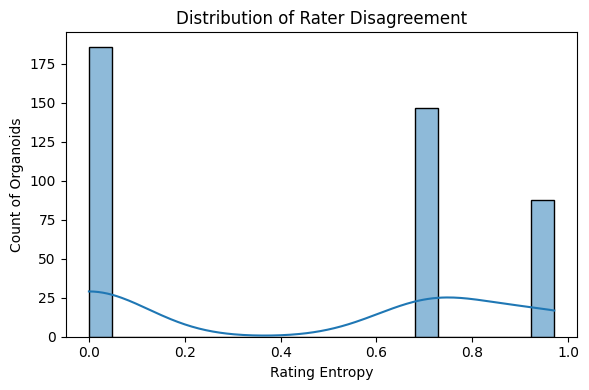

In [3]:
from scipy.stats import entropy

# Add entropy column to the DataFrame
def compute_entropy(ratings):
    counts = np.bincount(ratings, minlength=2)  # [count of 0s, count of 1s]
    probs = counts / counts.sum()
    return entropy(probs, base=2)  # base-2 for interpretability (0–1)

agreement_df["entropy"] = agreement_df["evals"].apply(compute_entropy)

# Top 10 most deviated based on entropy
most_deviated = agreement_df.sort_values(by="entropy", ascending=False).head(10)


plt.figure(figsize=(6, 4))
sns.histplot(agreement_df["entropy"], bins=20, kde=True)
plt.xlabel("Rating Entropy")
plt.ylabel("Count of Organoids")
plt.title("Distribution of Rater Disagreement")
plt.tight_layout()
plt.show()


In [19]:
import json
import pandas as pd
import numpy as np
from scipy.stats import entropy

# Load your survey data
with open("/home/amandabrooke/2025-promega-mini-test/surveys/organoid_surveys_aggregated.json", "r") as f:
    data = json.load(f)

# Flatten evaluations into DataFrame
records = []
for organoid_id, content in data.items():
    for e in content.get("evaluations", []):
        records.append({
            "organoid_id": organoid_id,
            "employee": e["employee"],
            "evaluation": e["evaluation"]
        })

df = pd.DataFrame(records)
df["eval_num"] = df["evaluation"].map({"Acceptable": 1, "Not Acceptable": 0})

# Calculate entropy and identify deviators
def compute_entropy_and_deviators(ratings, employees):
    counts = np.bincount(ratings, minlength=2)
    probs = counts / counts.sum()
    ent = entropy(probs, base=2)
    majority = 1 if counts[1] > counts[0] else 0
    deviators = [emp for emp, val in zip(employees, ratings) if val != majority]
    return ent, deviators

# Build the extended DataFrame
extended_stats = []
for organoid_id, group in df.groupby("organoid_id"):
    ratings = group["eval_num"].values
    employees = group["employee"].values
    ent, deviators = compute_entropy_and_deviators(ratings, employees)
    extended_stats.append({
        "organoid_id": organoid_id,
        "entropy": ent,
        "num_accept": (ratings == 1).sum(),
        "num_raters": len(ratings),
        "deviators": deviators,
        "evals": ratings.tolist()
    })

extended_df = pd.DataFrame(extended_stats)

# Top 10 most conflicted organoids
most_deviated = extended_df.sort_values(by="entropy", ascending=False).head(10)
print(most_deviated.to_string(index=False))


 organoid_id  entropy  num_accept  num_raters                           deviators           evals
 Organoid_96 0.970951           3           5  [Bruna Paulsen, Beatriz Guimaraes] [1, 0, 0, 1, 1]
 Organoid_66 0.970951           2           5  [Bruna Paulsen, Beatriz Guimaraes] [0, 1, 1, 0, 0]
 Organoid_61 0.970951           3           5 [Beatriz Guimaraes, Matheus Victor] [1, 1, 0, 1, 0]
 Organoid_54 0.970951           3           5 [Beatriz Guimaraes, Matheus Victor] [1, 1, 0, 1, 0]
 Organoid_67 0.970951           3           5     [Stevens Rehen, Matheus Victor] [1, 0, 1, 1, 0]
 Organoid_53 0.970951           3           5     [Stevens Rehen, Matheus Victor] [0, 1, 1, 1, 0]
Organoid_140 0.970951           3           5  [Beatriz Guimaraes, Bruna Paulsen] [0, 1, 0, 1, 1]
Organoid_153 0.970951           3           5 [Beatriz Guimaraes, Matheus Victor] [1, 1, 0, 1, 0]
Organoid_157 0.970951           2           5   [Bruna Paulsen, Livia Goto Silva] [0, 1, 0, 1, 0]
Organoid_139 0.97095

In [25]:
# --- DEBUG: Check mappings for known deviator organoids ---
organoid_ids_to_check = [
    "Organoid_96", "Organoid_66", "Organoid_61", "Organoid_54", "Organoid_67",
    "Organoid_53", "Organoid_140", "Organoid_153", "Organoid_157", "Organoid_139"
]

def reconstruct_full_ba(image_id):
    """
    Rebuild full BA string like 'BA2 96_1' from image_id string.
    """
    parts = image_id.strip().split()
    if len(parts) >= 3 and parts[0].upper().startswith("BA"):
        ba_full = f"{parts[0].upper()} {parts[1]}"
        return ba_full, parts[2], parts[3]  # BA, DayID, WellID
    else:
        return None, None, None

# Now test for top deviators
for oid in organoid_ids_to_check:
    print(f"\n⎯⎯⎯⎯⎯⎯⎯ {oid} ⎯⎯⎯⎯⎯⎯⎯")
    
    image_id = survey_data.get(oid, {}).get("image_id", "")
    ba_full, day_id, well_id = reconstruct_full_ba(image_id)
    
    if not all([ba_full, day_id, well_id]):
        print("❌ Failed to parse image_id:", image_id)
        continue

    key = f"{ba_full} {day_id} {well_id}"
    print(f"Parsed key: {key}")
    
    if key not in image_mapping:
        print("❌ Key not found in image_mapping.")
        continue

    image_path = image_mapping[key].get("Best Z Filename")
    print(f"✅ Found path: {image_path}")
    
    if not os.path.isfile(image_path):
        print("⚠️ File does not exist.")
    else:
        print("✅ File exists.")



⎯⎯⎯⎯⎯⎯⎯ Organoid_96 ⎯⎯⎯⎯⎯⎯⎯
Parsed key: BA1 96_1 Dy30 H11
✅ Found path: /net/projects2/promega/data-analysis/BA1/Dy30/Ba1 96_1 Dy30 H11 Z0.tif
✅ File exists.

⎯⎯⎯⎯⎯⎯⎯ Organoid_66 ⎯⎯⎯⎯⎯⎯⎯
Parsed key: BA1 96_1 Dy30 E5
✅ Found path: /net/projects2/promega/data-analysis/BA1/Dy30/Ba1 96_1 Dy30 E5 Z3.tif
✅ File exists.

⎯⎯⎯⎯⎯⎯⎯ Organoid_61 ⎯⎯⎯⎯⎯⎯⎯
Parsed key: BA1 96_1 Dy30 E11
✅ Found path: /net/projects2/promega/data-analysis/BA1/Dy30/Ba1 96_1 Dy30 E11 Z0.tif
✅ File exists.

⎯⎯⎯⎯⎯⎯⎯ Organoid_54 ⎯⎯⎯⎯⎯⎯⎯
Parsed key: BA1 96_1 Dy30 D5
✅ Found path: /net/projects2/promega/data-analysis/BA1/Dy30/Ba1 96_1 Dy30 D5 Z2.tif
✅ File exists.

⎯⎯⎯⎯⎯⎯⎯ Organoid_67 ⎯⎯⎯⎯⎯⎯⎯
Parsed key: BA1 96_1 Dy30 E6
✅ Found path: /net/projects2/promega/data-analysis/BA1/Dy30/Ba1 96_1 Dy30 E6 Z2.tif
✅ File exists.

⎯⎯⎯⎯⎯⎯⎯ Organoid_53 ⎯⎯⎯⎯⎯⎯⎯
Parsed key: BA1 96_1 Dy30 D4
✅ Found path: /net/projects2/promega/data-analysis/BA1/Dy30/Ba1 96_1 Dy30 D4 Z1.tif
✅ File exists.

⎯⎯⎯⎯⎯⎯⎯ Organoid_140 ⎯⎯⎯⎯⎯⎯⎯
Parsed key: BA2 96_1 Dy3

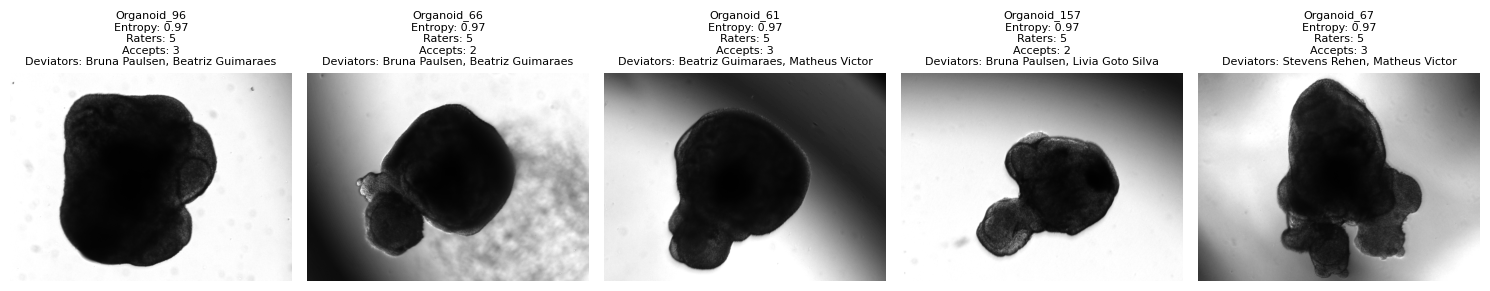

Total valid images: 5
['Organoid_96\nEntropy: 0.97\nRaters: 5\nAccepts: 3\nDeviators: Bruna Paulsen, Beatriz Guimaraes', 'Organoid_66\nEntropy: 0.97\nRaters: 5\nAccepts: 2\nDeviators: Bruna Paulsen, Beatriz Guimaraes', 'Organoid_61\nEntropy: 0.97\nRaters: 5\nAccepts: 3\nDeviators: Beatriz Guimaraes, Matheus Victor', 'Organoid_157\nEntropy: 0.97\nRaters: 5\nAccepts: 2\nDeviators: Bruna Paulsen, Livia Goto Silva', 'Organoid_67\nEntropy: 0.97\nRaters: 5\nAccepts: 3\nDeviators: Stevens Rehen, Matheus Victor']


In [30]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import entropy

# Load data
survey_path = "/home/amandabrooke/2025-promega-mini-test/surveys/organoid_surveys_aggregated.json"
mapping_path = "/net/projects2/promega/data-analysis/output/image_mapping.json"

with open(survey_path, "r") as f:
    survey_data = json.load(f)

with open(mapping_path, "r") as f:
    image_mapping = json.load(f)

# Sample top deviators provided
organoid_ids_to_check = [
    "Organoid_96", "Organoid_66", "Organoid_61", "Organoid_157", "Organoid_67"
]

# Function to reconstruct key and get image path
def reconstruct_full_ba(image_id):
    parts = image_id.strip().split()
    if len(parts) >= 4 and parts[0].upper().startswith("BA"):
        ba_full = f"{parts[0].upper()} {parts[1]}"
        return ba_full, parts[2], parts[3]
    return None, None, None

# Gather valid images and labels
valid_paths = []
valid_labels = []

for oid in organoid_ids_to_check:
    entry = survey_data.get(oid, {})
    image_id = entry.get("image_id", "")
    ba_full, day_id, well_id = reconstruct_full_ba(image_id)

    if not all([ba_full, day_id, well_id]):
        continue

    key = f"{ba_full} {day_id} {well_id}"
    if key not in image_mapping:
        continue

    image_path = image_mapping[key].get("Best Z Filename")
    if not os.path.isfile(image_path):
        continue

    # Build label
    evals = [e["evaluation"] for e in entry.get("evaluations", [])]
    raters = [e["employee"] for e in entry.get("evaluations", [])]
    eval_nums = [1 if val == "Acceptable" else 0 for val in evals]
    counts = np.bincount(eval_nums, minlength=2)
    probs = counts / counts.sum()
    ent = entropy(probs, base=2)
    majority = 1 if counts[1] > counts[0] else 0
    deviators = [r for r, v in zip(raters, eval_nums) if v != majority]

    label = (
        f"{oid}\n"
        f"Entropy: {ent:.2f}\n"
        f"Raters: {len(raters)}\n"
        f"Accepts: {sum(eval_nums)}\n"
        f"Deviators: {', '.join(deviators)}"
    )

    valid_paths.append(image_path)
    valid_labels.append(label)

# --- Load images robustly ---
def load_tif(path):
    img = tifffile.imread(path)
    # If image is multi-channel, use first channel
    if img.ndim == 3:
        img = img[0] if img.shape[0] < img.shape[-1] else img[..., 0]
    return img

images = [load_tif(p) for p in valid_paths]

# --- Plot ---
cols = len(images)
fig, axes = plt.subplots(1, cols, figsize=(3 * cols, 4))
if cols == 1:
    axes = [axes]  # Ensure iterable

for ax, img, label in zip(axes, images, valid_labels):
    ax.imshow(img, cmap="gray")
    ax.set_title(label, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Total valid images: {len(valid_paths)}")
print(valid_labels)



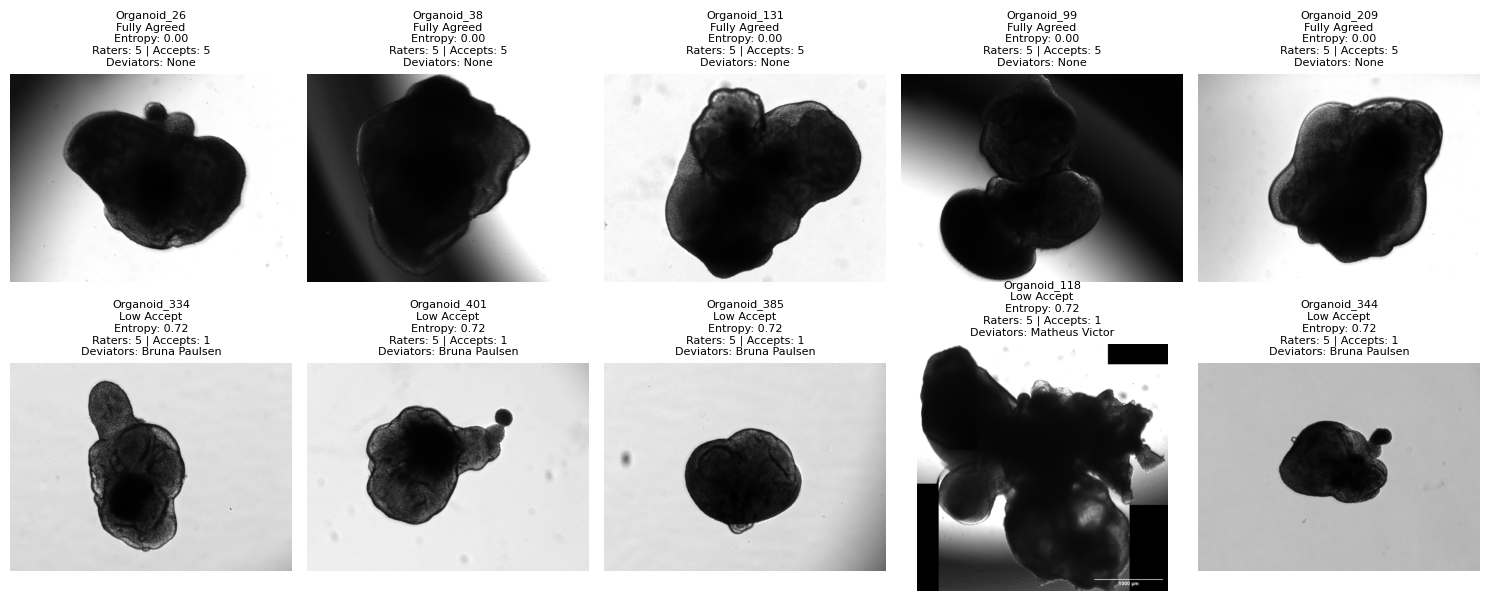

In [32]:
import json
import os
import tifffile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Load data
survey_path = "/home/amandabrooke/2025-promega-mini-test/surveys/organoid_surveys_aggregated.json"
mapping_path = "/net/projects2/promega/data-analysis/output/image_mapping.json"

with open(survey_path, "r") as f:
    survey_data = json.load(f)

with open(mapping_path, "r") as f:
    image_mapping = json.load(f)

# Function to reconstruct key and get image path
def reconstruct_full_ba(image_id):
    parts = image_id.strip().split()
    if len(parts) >= 4 and parts[0].upper().startswith("BA"):
        ba_full = f"{parts[0].upper()} {parts[1]}"
        return ba_full, parts[2], parts[3]
    return None, None, None

# Compute stats
records = []
for oid, entry in survey_data.items():
    evals = [1 if e["evaluation"] == "Acceptable" else 0 for e in entry.get("evaluations", [])]
    if not evals:
        continue
    records.append({
        "organoid_id": oid,
        "evals": evals,
        "num_accept": sum(evals),
        "agreement": evals.count(evals[0]) == len(evals) and len(evals) > 1
    })

stats_df = pd.DataFrame(records)

# Select top 5 from each group
fully_agreed_ids = stats_df[(stats_df["agreement"]) & (stats_df["num_accept"] == len(stats_df["evals"].iloc[0]))].head(5)["organoid_id"].tolist()
low_accept_ids = stats_df[stats_df["num_accept"] <= 1].head(5)["organoid_id"].tolist()

# Combine with labels
grouped_ids = [("Fully Agreed", fully_agreed_ids), ("Low Acceptance", low_accept_ids)]

# Function to collect images and labels
def collect_images_labels(organoid_ids, group_label):
    paths, labels = [], []
    for oid in organoid_ids:
        entry = survey_data.get(oid, {})
        image_id = entry.get("image_id", "")
        ba_full, day_id, well_id = reconstruct_full_ba(image_id)
        if not all([ba_full, day_id, well_id]):
            continue
        key = f"{ba_full} {day_id} {well_id}"
        if key not in image_mapping:
            continue
        image_path = image_mapping[key].get("Best Z Filename")
        if not os.path.isfile(image_path):
            continue
        evals = [1 if e["evaluation"] == "Acceptable" else 0 for e in entry.get("evaluations", [])]
        raters = [e["employee"] for e in entry.get("evaluations", [])]
        counts = np.bincount(evals, minlength=2)
        probs = counts / counts.sum()
        ent = entropy(probs, base=2)
        majority = 1 if counts[1] > counts[0] else 0
        deviators = [r for r, v in zip(raters, evals) if v != majority]
        label = (
            f"{oid}\n"
            f"{group_label}\n"
            f"Entropy: {ent:.2f}\n"
            f"Raters: {len(raters)} | Accepts: {sum(evals)}\n"
            f"Deviators: {', '.join(deviators) if deviators else 'None'}"
        )
        paths.append(image_path)
        labels.append(label)
    return paths, labels

# Gather all
top_paths, top_labels = collect_images_labels(fully_agreed_ids, "Fully Agreed")
low_paths, low_labels = collect_images_labels(low_accept_ids, "Low Accept")

# Load TIFs
def load_tif(path):
    img = tifffile.imread(path)
    if img.ndim == 3:
        img = img[0] if img.shape[0] < img.shape[-1] else img[..., 0]
    return img

top_images = [load_tif(p) for p in top_paths]
low_images = [load_tif(p) for p in low_paths]

# Plot
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, (images, labels) in enumerate([(top_images, top_labels), (low_images, low_labels)]):
    for col, (img, label) in enumerate(zip(images, labels)):
        ax = axes[row][col]
        ax.imshow(img, cmap="gray")
        ax.set_title(label, fontsize=8)
        ax.axis("off")

# Remove any empty subplots
for row_axes in axes:
    for ax in row_axes:
        if not ax.has_data():
            ax.axis("off")

plt.tight_layout()
plt.show()


In [35]:
from collections import defaultdict

# Step 1: Get majority vote per organoid
majority_map = {}

for organoid_id, group in df.groupby("organoid_id"):
    ratings = group["eval_num"].values
    if len(ratings) < 2:
        continue
    majority = 1 if (ratings == 1).sum() >= (ratings == 0).sum() else 0
    majority_map[organoid_id] = majority

# Step 2: Track agreement for each rater
rater_stats = defaultdict(lambda: {"agreed": 0, "total": 0})

for _, row in df.iterrows():
    oid = row["organoid_id"]
    rater = row["employee"]
    rating = row["eval_num"]

    if oid not in majority_map:
        continue

    majority = majority_map[oid]
    rater_stats[rater]["total"] += 1
    if rating == majority:
        rater_stats[rater]["agreed"] += 1

# Step 3: Format as DataFrame
rater_alignment = pd.DataFrame([
    {
        "rater": r,
        "total_rated": stats["total"],
        "agreed_with_majority": stats["agreed"],
        "alignment_fraction": stats["agreed"] / stats["total"] if stats["total"] > 0 else np.nan
    }
    for r, stats in rater_stats.items()
]).sort_values(by="alignment_fraction", ascending=True)

rater_alignment

,rater,total_rated,agreed_with_majority,alignment_fraction
2,Bruna Paulsen,421,319,0.757720
0,Beatriz Guimaraes,421,334,0.793349
1,Stevens Rehen,421,367,0.871734
3,Livia Goto Silva,421,380,0.902613
4,Matheus Victor,421,382,0.907363
